# 01 – General EDA · Porto Seguro Safe Driver Prediction

## 1. Setup & Bibliotheken
## 2. Daten laden & erster Blick

In [3]:
# Bibliothek laden und Setup einrichten

# Dateien und Ordner verwalten
from pathlib import Path

# Data-Stack
import numpy as np
import pandas as pd

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Ergebnisse reproduzieren

RANDOM_STATE = 42 # feste Zufallszahl 

In [5]:
# Daten laden

# Projekt-Root robust aus dem Notebook-Pfad ableiten.
# das Notebook liegt in members/S_S_R/notebooks/ -> Root ist drei Ebenen höher.

PROJECT_ROOT = Path.cwd().parents[2]
DATA_RAW = PROJECT_ROOT / "data" / "raw"

train = pd.read_csv(DATA_RAW / "train.csv")
test = pd.read_csv(DATA_RAW / "test.csv")

sample_submission = pd.read_csv(DATA_RAW / "sample_submission.csv")

print(f"train: {train.shape[0]:>8,} Zeilen x {train.shape[1]:>3} Spalten")
print(f"test : {test.shape[0]:>8,} Zeilen x {test.shape[1]:>3} Spalten")


train:  595,212 Zeilen x  59 Spalten
test :  892,816 Zeilen x  58 Spalten


In [6]:
train.head() # die ersten fünf Zeilen ansehen
train.info() # Datentypen und Speicherbedarf
train.describe().T # Kennzahlen aller numerischen Spalten (transponiert = lesbarer)

<class 'pandas.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_bin   59521

,count,mean,std,min,25%,50%,75%,max
id,595212.0,743803.558435,429367.820429,7.000000,371991.500000,743547.500000,1.115549e+06,1.488027e+06
target,595212.0,0.036448,0.187401,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00
ps_ind_01,595212.0,1.900378,1.983789,0.000000,0.000000,1.000000,3.000000e+00,7.000000e+00
ps_ind_02_cat,595212.0,1.358943,0.664594,-1.000000,1.000000,1.000000,2.000000e+00,4.000000e+00
ps_ind_03,595212.0,4.423318,2.699902,0.000000,2.000000,4.000000,6.000000e+00,1.100000e+01
ps_ind_04_cat,595212.0,0.416794,0.493311,-1.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
ps_ind_05_cat,595212.0,0.405188,1.350642,-1.000000,0.000000,0.000000,0.000000e+00,6.000000e+00
ps_ind_06_bin,595212.0,0.393742,0.488579,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
ps_ind_07_bin,595212.0,0.257033,0.436998,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
ps_ind_08_bin,595212.0,0.163921,0.370205,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00


In [8]:
# features gruppieren
# wir haben 57 anonyme features; es wäre hier fehleranfällig, jede Spalte händisch zu ordnen, 
# daher werden aus (vorher recherchierten) Namenskonventionen eine Meta-tabelle erstellt

# so können die jeweils binären/ kategorialen/ numerischen Spalten automatisch selektiert werden

def build_meta(df: pd.DataFrame) -> pd.DataFrame:
    """Leitet Rolle, Skalenniveau und Gruppe jedes Features aus dem Namen ab."""
    rows = []
    for col in df.columns:
        # Rolle im Modell
        if col == "target":
            role = "target"
        elif col == "id":
            role = "id"
        else:
            role = "input"

        # Skalenniveau aus Namens-Suffix bzw. Datentyp
        if col in ("id", "target"):
            level = col
        elif col.endswith("bin"):
            level = "binary"       # 0/1
        elif col.endswith("cat"):
            level = "nominal"      # Kategorie 
        elif df[col].dtype == "float64":
            level = "interval"     # kontinuierlich
        else:
            level = "ordinal"      # ganzzahlig 

        # Feature-Gruppe: ind / reg / car / calc
        group = col.split("_")[1] if col.startswith("ps_") else "meta"

        rows.append({
            "varname": col,
            "role": role,
            "level": level,
            "group": group,
            "dtype": str(df[col].dtype),
            "n_missing": int((df[col] == -1).sum()),
            "n_unique": int(df[col].nunique()),
        })
    return pd.DataFrame(rows).set_index("varname")

meta = build_meta(train)
meta.head(12)

,role,level,group,dtype,n_missing,n_unique
varname,,,,,,
id,id,id,meta,int64,0,595212
target,target,target,meta,int64,0,2
ps_ind_01,input,ordinal,ind,int64,0,8
ps_ind_02_cat,input,nominal,ind,int64,216,5
ps_ind_03,input,ordinal,ind,int64,0,12
ps_ind_04_cat,input,nominal,ind,int64,83,3
ps_ind_05_cat,input,nominal,ind,int64,5809,8
ps_ind_06_bin,input,binary,ind,int64,0,2
ps_ind_07_bin,input,binary,ind,int64,0,2


In [9]:
# (Veranschaulichung der Features-Gruppierung)

bin_cols = meta[meta.level == "binary"].index.tolist()
cat_cols = meta[meta.level == "nominal"].index.tolist()
num_cols = meta[meta.level.isin(["interval", "ordinal"])].index.tolist()

# überblick: wie viele Features je gruppe und skalenniveau?
meta.query("role == 'input'").groupby(["group", "level"]).size().unstack(fill_value=0)

level,binary,interval,nominal,ordinal
group,,,,
calc,6,3,0,11
car,0,4,11,1
ind,11,0,3,4
reg,0,3,0,0


## Verteilung der Ziel-Variablen

target
0    573518
1     21694
Name: count, dtype: int64
target
0    96.355
1     3.645
Name: proportion, dtype: float64


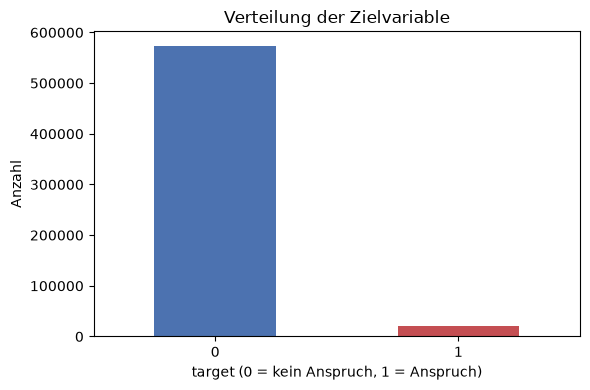

Anteil positiver Klasse: 3.6448%


In [10]:
# target - Verteilung

counts = train["target"].value_counts().sort_index()
share = train["target"].value_counts(normalize=True).sort_index()

print(counts)
print((share * 100).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Verteilung der Zielvariable")
ax.set_xlabel("target (0 = kein Anspruch, 1 = Anspruch)")
ax.set_ylabel("Anzahl")
ax.set_xticklabels(["0", "1"], rotation=0)
plt.tight_layout()
plt.show()

print(f"Anteil positiver Klasse: {train['target'].mean():.4%}")

In [11]:
# Fehlende Werte
# fehlende WErte werden durch -1 markiert
# Anzahl und Anteil der fehlenden Werte pro Feature bestimmen

missing = (train == -1).sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing_df = pd.DataFrame({
    "count-missing": missing,
    "percent_missing": (missing / len(train) * 100).round(2)
})
missing_df

,count-missing,percent_missing
ps_car_03_cat,411231,69.09
ps_car_05_cat,266551,44.78
ps_reg_03,107772,18.11
ps_car_14,42620,7.16
ps_car_07_cat,11489,1.93
ps_ind_05_cat,5809,0.98
ps_car_09_cat,569,0.10
ps_ind_02_cat,216,0.04
ps_car_01_cat,107,0.02
ps_ind_04_cat,83,0.01


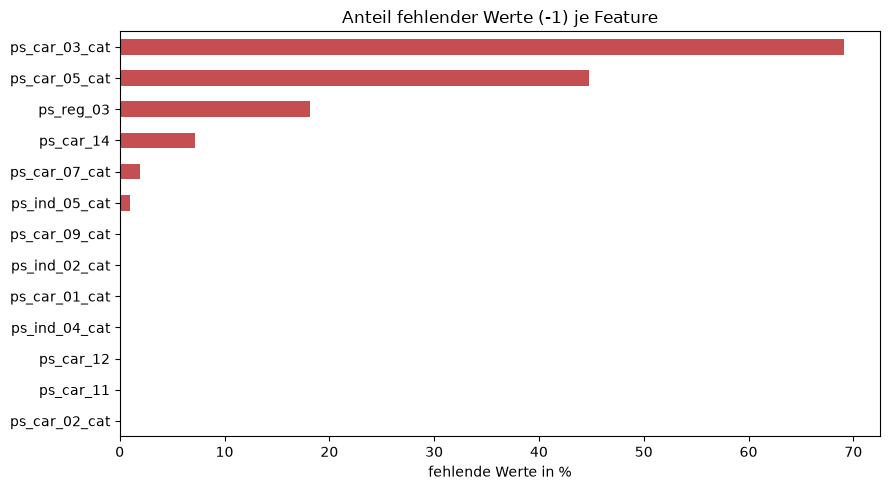

In [12]:
# Visualisierung zur Veranschaulichung

fig, ax = plt.subplots(figsize=(9, 5))
missing_df["percent_missing"].sort_values().plot(kind="barh", ax=ax, color="#C44E52")
ax.set_title("Anteil fehlender Werte (-1) je Feature")
ax.set_xlabel("fehlende Werte in %")
plt.tight_layout()
plt.show()

In [13]:
# arbeitskopie: -1 wird zu NaN, damit Kennzählen nicht verwässern/verfälscht werden

train_nan = train.replace(-1, np.nan)

# zudätzlich: anzahl fehlender Werte je Zeile

train["ps_n_missing"] = (train == -1).sum(axis=1)
train["ps_n_missing"].describe

<bound method NDFrame.describe of 0         1
1         2
2         3
3         0
4         2
         ..
595207    1
595208    3
595209    2
595210    2
595211    3
Name: ps_n_missing, Length: 595212, dtype: int64>

# Univariate Analyse - jedes Feature für sich verstehen

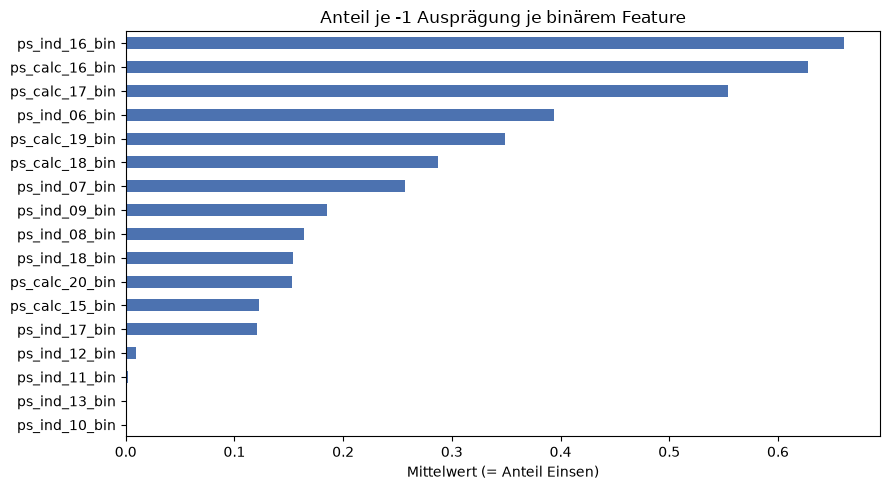

In [14]:
# binäre Features

bin_means = train[bin_cols].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
bin_means.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Anteil je -1 Ausprägung je binärem Feature")
ax.set_xlabel("Mittelwert (= Anteil Einsen)")
plt.tight_layout()
plt.show()



In [15]:
# kardinale Features

cat_card = train[cat_cols].nunique().sort_values(ascending=False)
cat_card

ps_car_11_cat    104
ps_car_06_cat     18
ps_car_01_cat     13
ps_car_04_cat     10
ps_ind_05_cat      8
ps_car_09_cat      6
ps_ind_02_cat      5
ps_ind_04_cat      3
ps_car_02_cat      3
ps_car_03_cat      3
ps_car_05_cat      3
ps_car_07_cat      3
ps_car_10_cat      3
ps_car_08_cat      2
dtype: int64

In [ ]:
# ordinale und numerische Features

train_nan[num_cols]


# Bivariate Analyse - Zusammenhänge verstehen

In [16]:
# numerisches Feature vs. target

num_corr = (train_nan[num_cols]
            .corrwith(train["target"])
            .abs()
            .sort_values(ascending=False))
num_corr.head(15)

ps_car_13     0.053899
ps_car_12     0.038800
ps_reg_02     0.034800
ps_reg_03     0.033758
ps_car_15     0.027667
ps_reg_01     0.022888
ps_ind_15     0.021506
ps_ind_01     0.018570
ps_car_14     0.011674
ps_ind_03     0.008360
ps_ind_14     0.007443
ps_calc_03    0.001907
ps_calc_01    0.001782
ps_calc_14    0.001362
ps_calc_02    0.001360
dtype: float64

In [18]:
# kategoriales feature vs. target

def target_rate_by_category(df, col, target="target"):
    """Anspruchsrate und häufigkeit je kategorie eines Features"""

    grp = (df.groupby(col)[target]
          .agg(target_rate="mean", n="count")
          .sort_values("target_rate", ascending=False))
    return grp


target_rate_by_category(train, "ps_ind_05_cat")

,target_rate,n
ps_ind_05_cat,,
-1,0.083319,5809
2,0.075526,4184
6,0.059336,20662
4,0.052061,18344
5,0.048514,1649
1,0.047825,8322
3,0.042998,8233
0,0.033865,528009


In [20]:
# binäres Feature vs. target
# für jedes binäre Feature die Anspruchsrate in Gruppe 0 vs 1 vergleichen

bin_analyse = pd.DataFrame({
    "rate_bei_0": [train.loc[train[c] == 0, "target"].mean() for c in bin_cols],
    "rate_bei_1": [train.loc[train[c] == 1, "target"].mean() for c in bin_cols],

}, index=bin_cols)

bin_analyse["differenz"] = (bin_analyse["rate_bei_1"] - bin_analyse["rate_bei_0"]).abs()
bin_analyse.sort_values("differenz", ascending=False).head(10)

,rate_bei_0,rate_bei_1,differenz
ps_ind_17_bin,0.033870,0.055155,0.021285
ps_ind_10_bin,0.036441,0.054054,0.017613
ps_ind_12_bin,0.036305,0.051442,0.015137
ps_ind_13_bin,0.036433,0.051418,0.014985
ps_ind_07_bin,0.032676,0.047350,0.014674
ps_ind_06_bin,0.041585,0.028537,0.013048
ps_ind_16_bin,0.043714,0.032718,0.010996
ps_ind_11_bin,0.036432,0.045680,0.009248
ps_ind_08_bin,0.035357,0.042012,0.006655
ps_ind_09_bin,0.037184,0.033211,0.003973


# Korrelationsanalyse

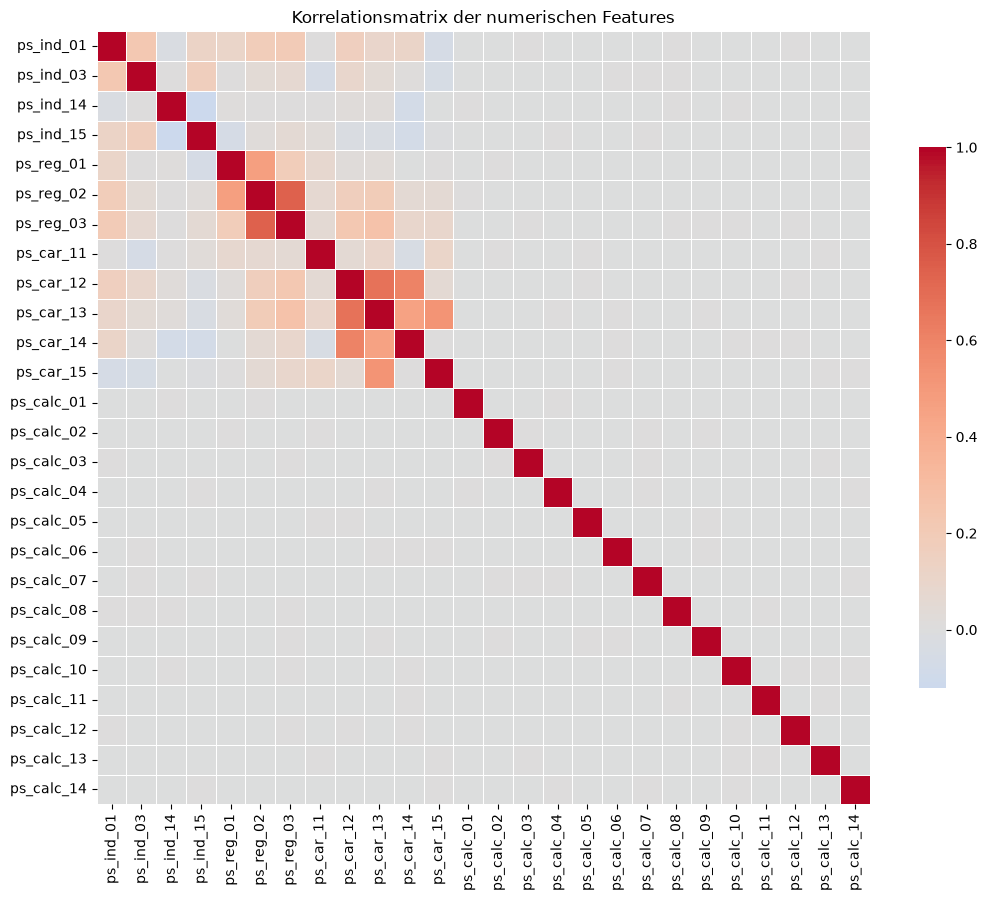

In [21]:
# Korrelationsmatrix berechnen
corr = train_nan[num_cols].corr()

# Figure und Achsen erstellen
fig, ax = plt.subplots(figsize=(11, 9))

# Heatmap zeichnen
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .7},
    ax=ax
)

# Titel hinzufügen
ax.set_title("Korrelationsmatrix der numerischen Features")

# Layout optimieren
plt.tight_layout()

# Grafik anzeigen
plt.show()

In [25]:
# Sonderfall: ps_calc (da wenig informativ)

calc_cols = meta[meta.group == "calc"].index.tolist()

calc_corr = (train[calc_cols]
             .corrwith(train["target"])
             .abs()
             .sort_values(ascending=False))
calc_corr.head(10)


ps_calc_03        0.001907
ps_calc_01        0.001782
ps_calc_19_bin    0.001744
ps_calc_14        0.001362
ps_calc_02        0.001360
ps_calc_12        0.001133
ps_calc_20_bin    0.001072
ps_calc_10        0.001061
ps_calc_08        0.001006
ps_calc_05        0.000771
dtype: float64